# 1. Importing Packages

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightgbm as lgb
import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

# 2. Data Pre-processing

In [2]:
df = pd.read_csv("household_power_consumption.txt", sep=';', na_values='?')

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df = df.sort_values('datetime')

df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
df = df.dropna(subset=['Global_active_power'])

df = df[['datetime', 'Global_active_power']]
df.head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9260\257981067.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


,datetime,Global_active_power
0,2006-12-16 17:24:00,4.216
1,2006-12-16 17:25:00,5.360
2,2006-12-16 17:26:00,5.374
3,2006-12-16 17:27:00,5.388
4,2006-12-16 17:28:00,3.666


In [3]:
df['minute']        = df['datetime'].dt.minute
df['hour']          = df['datetime'].dt.hour
df['minute_of_day'] = df['hour']*60 + df['minute']
df['dayofweek']     = df['datetime'].dt.dayofweek
df['dayofmonth']    = df['datetime'].dt.day
df['month']         = df['datetime'].dt.month
df['year']          = df['datetime'].dt.year
df['is_weekend']    = (df['dayofweek'] >= 5).astype(int)

def cyclical(series, max_val):
    return np.sin(2*np.pi*series/max_val), np.cos(2*np.pi*series/max_val)

df['hour_sin'],  df['hour_cos']  = cyclical(df['hour'],          24)
df['min_sin'],   df['min_cos']   = cyclical(df['minute_of_day'], 1440)
df['dow_sin'],   df['dow_cos']   = cyclical(df['dayofweek'],     7)
df['month_sin'], df['month_cos'] = cyclical(df['month'],         12)

LAG_STEPS = [1, 2, 3, 5, 10, 15, 30, 60, 90, 120]
for lag in LAG_STEPS:
    df[f'lag_{lag}'] = df['Global_active_power'].shift(lag)

df['lag_1day']  = df['Global_active_power'].shift(1440)
df['lag_1week'] = df['Global_active_power'].shift(1440*7)

for w in [15, 30, 60, 120]:
    rolled = df['Global_active_power'].shift(1).rolling(w, min_periods=1)
    df[f'roll_mean_{w}'] = rolled.mean()
    df[f'roll_std_{w}']  = rolled.std().fillna(0)

df = df.dropna().reset_index(drop=True)
df.shape

(2039200, 38)

In [4]:
df.head()

,datetime,Global_active_power,minute,hour,minute_of_day,dayofweek,dayofmonth,month,year,is_weekend,...,lag_1day,lag_1week,roll_mean_15,roll_std_15,roll_mean_30,roll_std_30,roll_mean_60,roll_std_60,roll_mean_120,roll_std_120
0,2006-12-23 17:26:00,4.848,26,17,1046,5,23,12,2006,1,...,1.870,4.216,4.592267,0.630402,5.347600,1.336228,4.833933,1.168931,4.529817,1.108417
1,2006-12-23 17:27:00,4.858,27,17,1047,5,23,12,2006,1,...,1.874,5.360,4.579733,0.622773,5.431467,1.213777,4.842833,1.166936,4.532400,1.108797
2,2006-12-23 17:28:00,4.862,28,17,1048,5,23,12,2006,1,...,1.874,5.374,4.572533,0.618598,5.482000,1.153866,4.844800,1.166859,4.534767,1.109190
3,2006-12-23 17:29:00,4.930,29,17,1049,5,23,12,2006,1,...,1.880,5.388,4.566667,0.615170,5.421733,1.136766,4.847033,1.166760,4.542133,1.108396
4,2006-12-23 17:30:00,5.006,30,17,1050,5,23,12,2006,1,...,1.918,3.666,4.570000,0.617122,5.342267,1.081929,4.850667,1.166672,4.563350,1.090969


In [5]:
df.columns

Index(['datetime', 'Global_active_power', 'minute', 'hour', 'minute_of_day',
       'dayofweek', 'dayofmonth', 'month', 'year', 'is_weekend', 'hour_sin',
       'hour_cos', 'min_sin', 'min_cos', 'dow_sin', 'dow_cos', 'month_sin',
       'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'lag_15',
       'lag_30', 'lag_60', 'lag_90', 'lag_120', 'lag_1day', 'lag_1week',
       'roll_mean_15', 'roll_std_15', 'roll_mean_30', 'roll_std_30',
       'roll_mean_60', 'roll_std_60', 'roll_mean_120', 'roll_std_120'],
      dtype='object')

# 3. Data Visualization

### 3.1 Average Electricity Consumption Throughout the Day

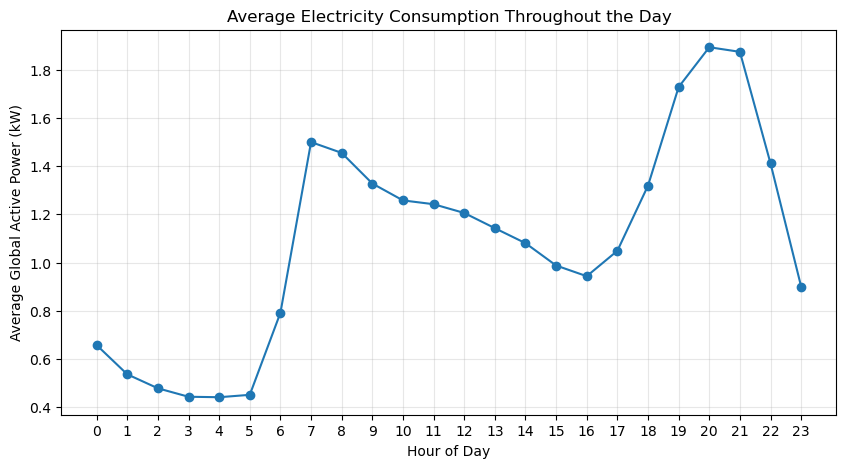

In [24]:
# Group by hour and take average consumption
hourly_avg = df.groupby('hour')['Global_active_power'].mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(hourly_avg.index, hourly_avg.values, marker='o')
plt.title('Average Electricity Consumption Throughout the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.show()

### 3.2 Average Electricity Usage by Day of Week

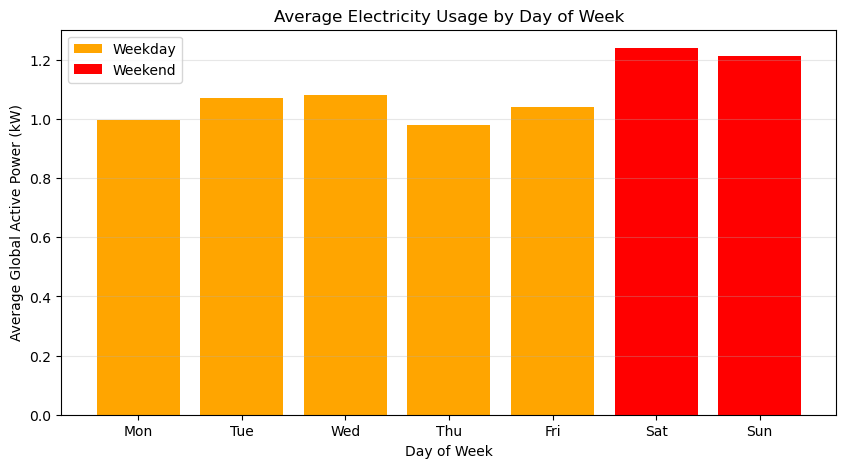

In [28]:
# Average usage per day of week
dow_avg = df.groupby('dayofweek')['Global_active_power'].mean()

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = ['orange','orange','orange','orange','orange','red','red']

# Plot
plt.figure(figsize=(10,5))
plt.bar(dow_avg.index, dow_avg.values, color=colors)
plt.title('Average Electricity Usage by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(ticks=range(7), labels=days)

legend_elements = [Patch(facecolor='orange', label='Weekday'), Patch(facecolor='red', label='Weekend')]
plt.legend(handles=legend_elements)
plt.grid(axis='y', alpha=0.3)
plt.show()

### 3.3 Average Electricity Consumption by Month

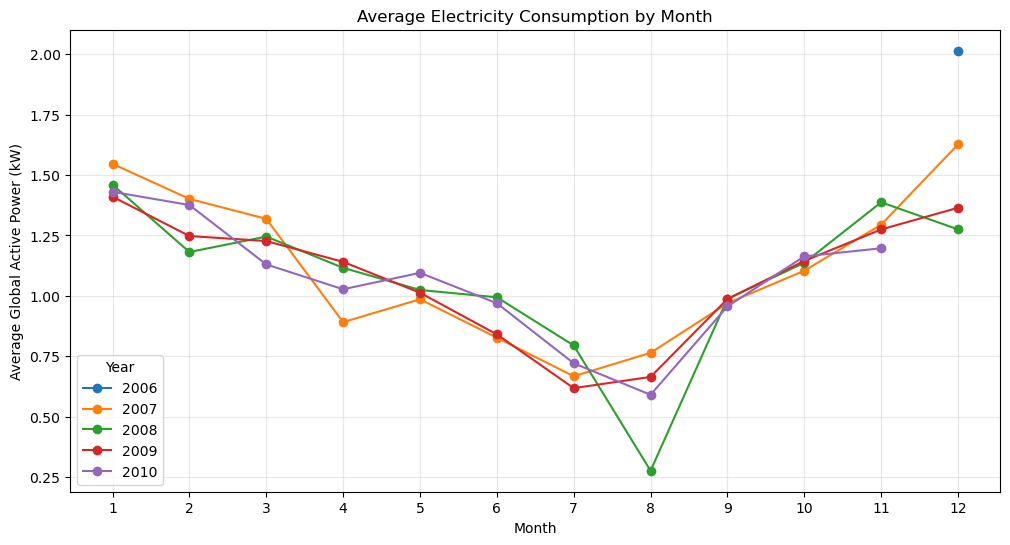

In [67]:
# Group by year and month
monthly_yearly_avg = df.groupby(['year', 'month'])['Global_active_power'].mean().unstack()

# Plot
plt.figure(figsize=(12,6))
for year in monthly_yearly_avg.index:
    plt.plot(monthly_yearly_avg.columns, monthly_yearly_avg.loc[year], marker='o', label=str(year))

plt.title('Average Electricity Consumption by Month')
plt.xlabel('Month')
plt.ylabel('Average Global Active Power (kW)')
plt.xticks(range(1,13))
plt.grid(alpha=0.3)
plt.legend(title='Year')
plt.show()

# 4. Train-Test Split

In [6]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

features = [col for col in df.columns if col not in ['datetime', 'Global_active_power']]

X_train, y_train = train[features], train['Global_active_power']
X_test, y_test = test[features], test['Global_active_power']

In [7]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1631360, 36)
y_train: (1631360,)
X_test: (407840, 36)
y_test: (407840,)


# 5. Defining Evaluation Metrics

In [8]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R2   : {r2:.4f}")
    return {'Model': name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

In [9]:
results = []

# 6. Model Training

### 6.1 Ridge Regression

In [10]:
scaler_ridge = StandardScaler()
X_train_sc   = scaler_ridge.fit_transform(X_train)
X_test_sc    = scaler_ridge.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

results.append(evaluate('Ridge Regression', y_test, y_pred_ridge))


Ridge Regression
MAE  : 0.0855
RMSE : 0.2200
R2   : 0.9396


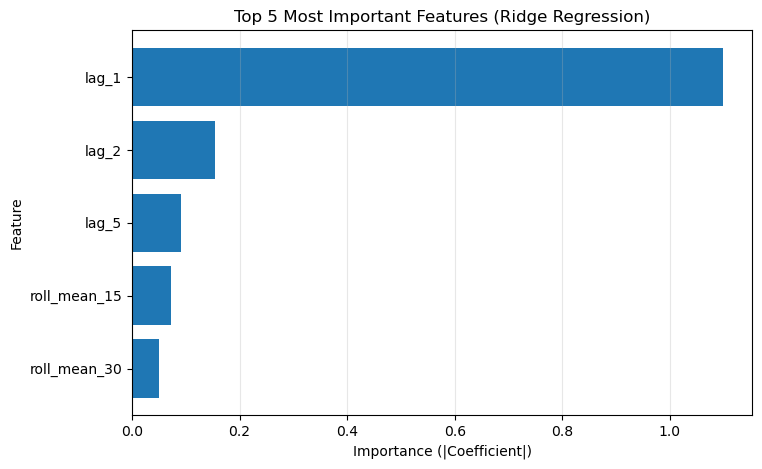

In [36]:
# Get feature importance (absolute value of coefficients)
importance = np.abs(ridge.coef_)
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(5)

# Plot horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Top 5 Most Important Features (Ridge Regression)')
plt.xlabel('Importance (|Coefficient|)')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 6.2 Random Forest

In [11]:
rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate('Random Forest', y_test, y_pred_rf))


Random Forest
MAE  : 0.0741
RMSE : 0.2055
R2   : 0.9473


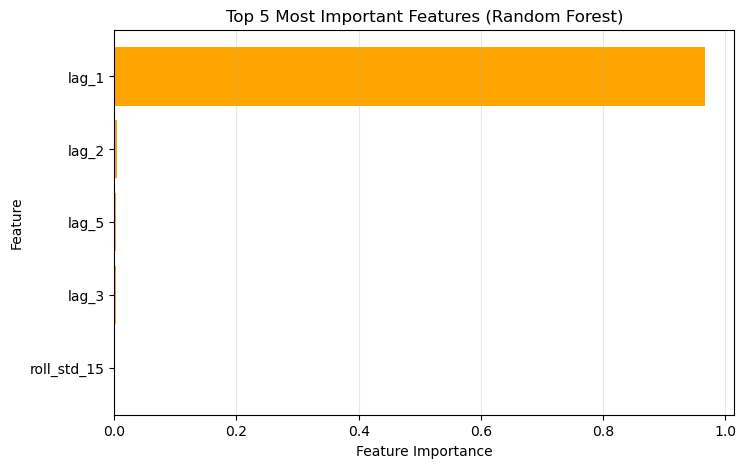

In [39]:
# Get feature importance
importance = rf.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(5)

# Plot horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'], color='orange')
plt.gca().invert_yaxis()
plt.title('Top 5 Most Important Features (Random Forest)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 6.3 XGBoost

In [12]:
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                             subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                             reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate('XGBoost', y_test, y_pred_xgb))


XGBoost
MAE  : 0.0766
RMSE : 0.2060
R2   : 0.9471


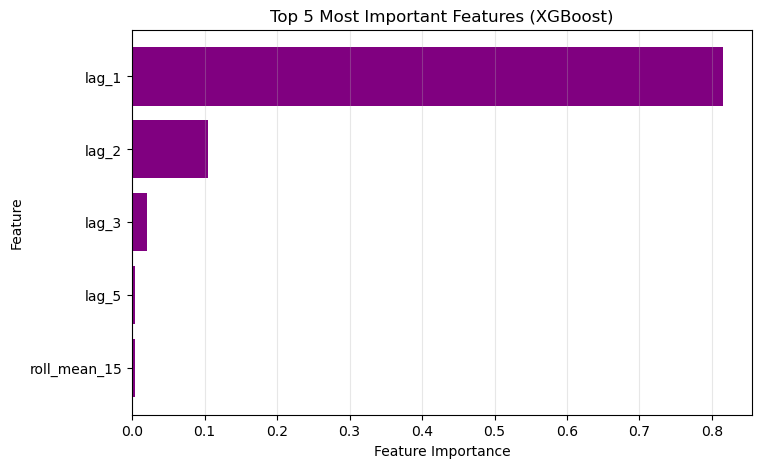

In [34]:
# Get feature importance
importance = xgb_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(5)

# Plot horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'], color='purple')
plt.gca().invert_yaxis()
plt.title('Top 5 Most Important Features (XGBoost)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 6.4 LightGBM

In [13]:
lgb_model = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.03, num_leaves=127, max_depth=10,
                              min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                              reg_alpha=0.1, reg_lambda=1.0, random_state=42, n_jobs=-1, verbose=0)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
y_pred_lgb = lgb_model.predict(X_test)

results.append(evaluate('LightGBM', y_test, y_pred_lgb))


LightGBM
MAE  : 0.0764
RMSE : 0.2055
R2   : 0.9473


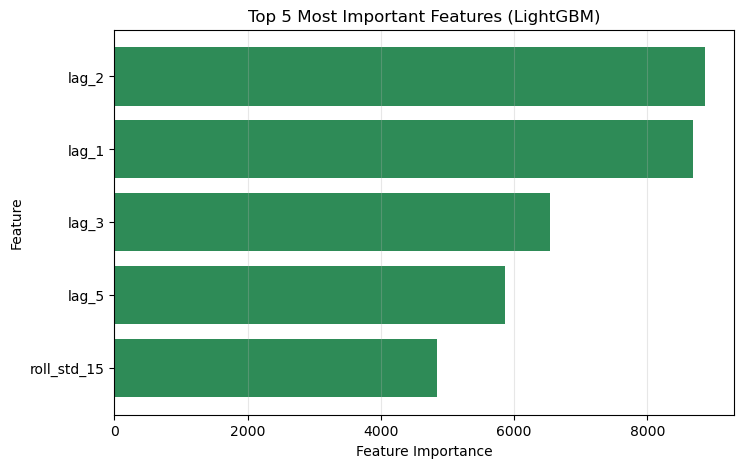

In [40]:
# Get feature importance
importance = lgb_model.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': importance})
top_features = feature_importance.sort_values(by='Importance', ascending=False).head(5)

# Plot horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'], color='seagreen')
plt.gca().invert_yaxis()
plt.title('Top 5 Most Important Features (LightGBM)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.show()

### 6.5 LSTM

In [14]:
seq_len = 60        # use last 60 minutes
batch_size = 1024
epochs = 5

lstm_features = ['Global_active_power', 'hour_sin', 'hour_cos', 'min_sin', 'min_cos',
                 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
lstm_df = df[['datetime'] + lstm_features].copy()

train_data = lstm_df[lstm_features].iloc[:split].values
test_data  = lstm_df[lstm_features].iloc[split:].values

scaler = MinMaxScaler()
scaler.fit(train_data)
train_scaled = scaler.transform(train_data)
test_scaled  = scaler.transform(test_data)

target_index = lstm_features.index('Global_active_power')

print("Features used:", lstm_features)
print("Sequence length:", seq_len)
print("Target column index:", target_index)

Features used: ['Global_active_power', 'hour_sin', 'hour_cos', 'min_sin', 'min_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend']
Sequence length: 60
Target column index: 0


In [15]:
def create_sequences(data, seq_len, target_col_idx):
    X, y = [], []

    for i in range(len(data) - seq_len):
        # Take a window of past 'seq_len' steps
        X.append(data[i : i + seq_len])
        
        # Target is the next timestep value
        y.append(data[i + seq_len, target_col_idx])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Take last 'seq_len' rows from training data
context = train_scaled[-seq_len:]
# Attach it before test data
test_with_context = np.vstack([context, test_scaled])

X_lstm_train, y_lstm_train = create_sequences(train_scaled, seq_len, target_index)
X_lstm_test, y_lstm_test = create_sequences(test_with_context, seq_len, target_index)

print("Train sequences:", X_lstm_train.shape, "Labels:", y_lstm_train.shape)
print("Test sequences :", X_lstm_test.shape,  "Labels:", y_lstm_test.shape)

Train sequences: (1631300, 60, 10) Labels: (1631300,)
Test sequences : (407840, 60, 10) Labels: (407840,)


In [16]:
n_features = X_lstm_train.shape[2]

def build_lstm_model(seq_len, num_features):

    model = Sequential()

    # First LSTM layer
    model.add(LSTM(128, return_sequences=True, input_shape=(seq_len, num_features)))
    model.add(Dropout(0.2))

    # Second LSTM layer
    model.add(LSTM(64))
    model.add(Dropout(0.2))

    # Dense layers
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='huber')

    return model


# Build model
lstm_model = build_lstm_model(seq_len, n_features)

# Show summary
lstm_model.summary()

C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,689 (479.25 KB)

 Trainable params: 122,689 (479.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Callbacks (to improve training efficiency)

callbacks = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
             ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
             ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True, verbose=0)]


# Training the LSTM model

history = lstm_model.fit( X_lstm_train, y_lstm_train, validation_data=(X_lstm_test, y_lstm_test), epochs=epochs,
                         batch_size=batch_size, callbacks=callbacks, verbose=1)

print("LSTM training finished.")

Epoch 1/5
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 821s 511ms/step - loss: 0.0012 - val_loss: 2.0825e-04 - learning_rate: 0.0010
Epoch 2/5
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 861s 510ms/step - loss: 3.4288e-04 - val_loss: 2.0423e-04 - learning_rate: 0.0010
Epoch 3/5
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 818s 513ms/step - loss: 3.2467e-04 - val_loss: 2.1310e-04 - learning_rate: 0.0010
Epoch 4/5
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - loss: 3.1281e-04
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 819s 514ms/step - loss: 3.1281e-04 - val_loss: 2.4557e-04 - learning_rate: 0.0010
Epoch 5/5
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 813s 510ms/step - loss: 3.0167e-04 - val_loss: 2.2525e-04 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 2.
LSTM training finished.


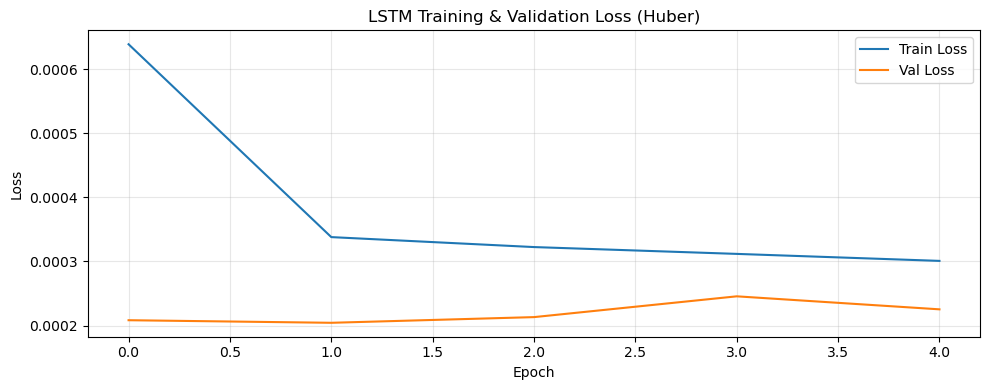

In [18]:
# Plot training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training & Validation Loss (Huber)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_loss_curve.png', dpi=150)
plt.show()

In [19]:
y_pred_scaled = lstm_model.predict(X_lstm_test, batch_size=batch_size).flatten()

# Convert predictions back to original scale
dummy_pred = np.zeros((len(y_pred_scaled), len(lstm_features)))
dummy_pred[:, target_index] = y_pred_scaled

# Get actual predicted values in kW
y_pred = scaler.inverse_transform(dummy_pred)[:, target_index]

# Do the same for true values
dummy_true = np.zeros((len(y_lstm_test), len(lstm_features)))
dummy_true[:, target_index] = y_lstm_test
y_true = scaler.inverse_transform(dummy_true)[:, target_index]

# Evaluating model performance

results.append(evaluate('LSTM', y_true, y_pred))

399/399 ━━━━━━━━━━━━━━━━━━━━ 91s 227ms/step

LSTM
MAE  : 0.0965
RMSE : 0.2232
R2   : 0.9378


# 7. Metrics Comparison of all Models

In [21]:
# ---- Create Final Comparison Table ----

results_df = pd.DataFrame(results)

# Sort by best model (highest R2)
results_df = results_df.sort_values(by='R2', ascending=False)

# Round values for readability
results_df = results_df.round(4)

# Set Model as index
results_df.set_index('Model', inplace=True)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)


FINAL MODEL COMPARISON
                      R2     MAE    RMSE
Model                                   
LightGBM          0.9473  0.0764  0.2055
Random Forest     0.9473  0.0741  0.2055
XGBoost           0.9471  0.0766  0.2060
Ridge Regression  0.9396  0.0855  0.2200
LSTM              0.9378  0.0965  0.2232


# 8. Final Model Conclusion

### **Best Model → LightGBM**

### 8.1 Key Observations

- All models performed very well, with R² scores above 0.93, indicating strong predictive capability.

- Tree-based models (LightGBM, Random Forest, XGBoost) performed almost identically,  
  with extremely small differences (less than 0.001 in R²).

- LightGBM achieved the best overall performance, with the highest R² and competitive error metrics (MAE, RMSE).

- Random Forest and XGBoost are also strong alternatives, showing nearly identical performance.

- Ridge Regression performed reasonably well but was outperformed by ensemble methods.

- LSTM (Deep Learning model) performed slightly worse, likely due to limited training epochs (each epoch takes a lot of time to train)

### 8.2 Final Insight

Considering all factors, **LightGBM is the most suitable model for this problem.**

# 9. LightGBM: Comparing Actual vs Predicted

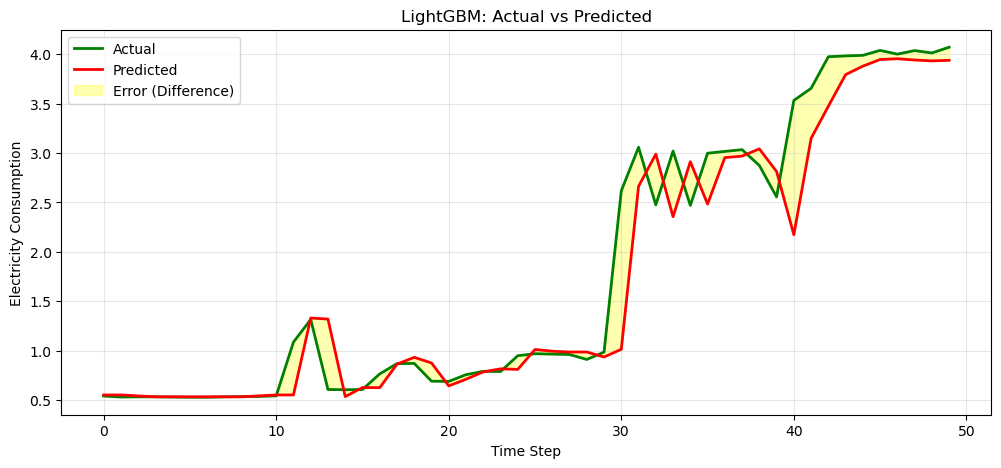

In [66]:
y_true = np.array(y_test)
y_pred = np.array(y_pred_lgb)

# Taking a subset for better visualization
n = 50
y_true = y_true[:n]
y_pred = y_pred[:n]

plt.figure(figsize=(12,5))
plt.plot(y_true, label='Actual', linewidth=2, color='green')
plt.plot(y_pred, label='Predicted', linewidth=2, color='red')
plt.fill_between(range(len(y_true)), y_true, y_pred, alpha=0.3, label='Error (Difference)', color='yellow')
plt.title('LightGBM: Actual vs Predicted')
plt.xlabel('Time Step')
plt.ylabel('Electricity Consumption')
plt.legend()
plt.grid(alpha=0.3)
plt.show()